In [4]:
import duckdb as db 
import pandas as pd 
import numpy as np 
import xgboost as xg
import pyarrow

In [3]:
DATA_PATH = "2022_place_canvas_history.parquet"

In [5]:
con = db.connect("rplace.duckdb")

In [6]:
con.execute(
    f"""
    CREATE OR REPLACE TABLE events AS
    SELECT
        user_id,
        timestamp,
        pixel_color,
        TRY_CAST(regexp_extract(coordinate, '(-?\d+)\s*,\s*(-?\d+)', 1) AS INTEGER) AS x,
        TRY_CAST(regexp_extract(coordinate, '(-?\d+)\s*,\s*(-?\d+)', 2) AS INTEGER) AS y
    FROM raw
    WHERE coordinate IS NOT NULL;
    """
    )

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/var/folders/47/t0qjk26j299g0zrd5rmmnp7w0000gn/T/ipykernel_15490/1515510843.py:12: SyntaxWarning: invalid escape sequence '\d'
  """


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
print(con.execute(
    """
    SELECT
        COUNT(*) AS n,
        COUNT(*) FILTER (WHERE x IS NULL OR y IS NULL) AS bad_coords
    FROM events;
    """).fetch_df()
)

           n  bad_coords
0  160353104           0


In [12]:
print(con.execute(
    "SELECT * FROM raw ORDER BY timestamp LIMIT 10").fetchdf()
)

                timestamp               user_id pixel_color coordinate
0 2022-04-01 12:44:10.315   2447141340840567702     #7EED56      42,42
1 2022-04-01 12:44:22.671   7104006806047954359     #00A368    999,999
2 2022-04-01 12:44:26.626  13253107030314978575     #3690EA      44,42
3 2022-04-01 12:44:31.703  12510680673639030957     #D4D7D9        2,2
4 2022-04-01 12:44:44.409   8260948853351027725     #3690EA      23,23
5 2022-04-01 12:44:50.544  13648917610020509812     #2450A4    420,420
6 2022-04-01 12:45:17.836  18064103172119694350     #51E9F4     110,37
7 2022-04-01 12:45:18.967  11662327462892008208     #2450A4     420,69
8 2022-04-01 12:45:36.012  17412569827241543765     #811E9F       5,29
9 2022-04-01 12:45:51.328  14749529878349148760     #FFFFFF    313,759


In [11]:
print(con.execute(
    "SELECT * FROM events ORDER BY timestamp LIMIT 10").fetchdf()
)

                user_id               timestamp pixel_color    x    y
0   2447141340840567702 2022-04-01 12:44:10.315     #7EED56   42   42
1   7104006806047954359 2022-04-01 12:44:22.671     #00A368  999  999
2  13253107030314978575 2022-04-01 12:44:26.626     #3690EA   44   42
3  12510680673639030957 2022-04-01 12:44:31.703     #D4D7D9    2    2
4   8260948853351027725 2022-04-01 12:44:44.409     #3690EA   23   23
5  13648917610020509812 2022-04-01 12:44:50.544     #2450A4  420  420
6  18064103172119694350 2022-04-01 12:45:17.836     #51E9F4  110   37
7  11662327462892008208 2022-04-01 12:45:18.967     #2450A4  420   69
8  17412569827241543765 2022-04-01 12:45:36.012     #811E9F    5   29
9  14749529878349148760 2022-04-01 12:45:51.328     #FFFFFF  313  759


In [13]:
con.execute(
    """CREATE TABLE pixel_minute AS
    SELECT
        x,
        y,
        date_trunc('minute', timestamp) AS t_min,
        COUNT(*) AS edits,
        COUNT(DISTINCT user_id) AS users
    FROM events
    GROUP BY 1, 2, 3
    """
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [19]:
print(con.execute("SELECT COUNT(*) FROM pixel_minute").fetchone())

print(con.execute("""
SELECT *
FROM pixel_minute
ORDER BY t_min ASC
LIMIT 30
""").fetchdf())

print(con.execute("""
SELECT
  MIN(edits) AS min_edits,
  MAX(edits) AS max_edits,
  AVG(edits) AS avg_edits
FROM pixel_minute
""").fetchdf())


(106207844,)
      x    y               t_min  edits  users
0    23   23 2022-04-01 12:44:00      1      1
1     2    2 2022-04-01 12:44:00      1      1
2   999  999 2022-04-01 12:44:00      1      1
3    44   42 2022-04-01 12:44:00      1      1
4    42   42 2022-04-01 12:44:00      1      1
5   420  420 2022-04-01 12:44:00      1      1
6     5   29 2022-04-01 12:45:00      1      1
7   110   37 2022-04-01 12:45:00      1      1
8   420   69 2022-04-01 12:45:00      1      1
9   313  759 2022-04-01 12:45:00      1      1
10    0    0 2022-04-01 12:46:00      1      1
11    5   29 2022-04-01 12:48:00      2      2
12    5   29 2022-04-01 12:50:00      1      1
13  902  982 2022-04-01 12:52:00      1      1
14    1    1 2022-04-01 12:52:00      1      1
15  725  214 2022-04-01 12:53:00      1      1
16   16   19 2022-04-01 12:53:00      1      1
17  333  333 2022-04-01 12:54:00      1      1
18  299  200 2022-04-01 13:02:00      1      1
19  501  457 2022-04-01 13:03:00      1      1


In [20]:
print(con.execute("""
SELECT
  date_trunc('hour', timestamp) AS hour,
  COUNT(*) AS edits,
  COUNT(DISTINCT user_id) AS users,
  COUNT(DISTINCT x || ',' || y) AS pixels_touched
FROM events
GROUP BY 1
ORDER BY 1;
""").fetchdf())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                  hour    edits    users  pixels_touched
0  2022-04-01 12:00:00       19       19              16
1  2022-04-01 13:00:00   548768   258215          323778
2  2022-04-01 14:00:00   867841   337002          421530
3  2022-04-01 15:00:00   996922   376552          396024
4  2022-04-01 16:00:00  1070924   404836          352168
..                 ...      ...      ...             ...
80 2022-04-04 20:00:00  4904535  1706608          851478
81 2022-04-04 21:00:00  5901535  1708498          817875
82 2022-04-04 22:00:00  5640526  1562214         1279174
83 2022-04-04 23:00:00  3057385  1246307         2699264
84 2022-04-05 00:00:00   320010   269654          256678

[85 rows x 4 columns]


In [10]:

print(con.execute("""
SELECT
  date_trunc('hour', timestamp) AS hour,
  COUNT(*) AS edits
FROM events
GROUP BY 1
ORDER BY edits DESC
LIMIT 30;
""").fetchdf())

                  hour    edits
0  2022-04-04 21:00:00  5901535
1  2022-04-04 22:00:00  5640526
2  2022-04-04 20:00:00  4904535
3  2022-04-04 19:00:00  4568075
4  2022-04-03 21:00:00  4480173
5  2022-04-04 16:00:00  4033642
6  2022-04-04 18:00:00  3917284
7  2022-04-04 17:00:00  3866703
8  2022-04-03 22:00:00  3717327
9  2022-04-04 15:00:00  3607029
10 2022-04-03 23:00:00  3517127
11 2022-04-03 19:00:00  3434298
12 2022-04-03 20:00:00  3426663
13 2022-04-04 23:00:00  3057385
14 2022-04-04 14:00:00  2804684
15 2022-04-04 00:00:00  2726752
16 2022-04-04 01:00:00  2573111
17 2022-04-04 13:00:00  2554902
18 2022-04-03 18:00:00  2523721
19 2022-04-03 17:00:00  2486874
20 2022-04-04 02:00:00  2355087
21 2022-04-03 16:00:00  2318605
22 2022-04-04 12:00:00  2172131
23 2022-04-02 20:00:00  2036968
24 2022-04-03 15:00:00  2007016
25 2022-04-04 03:00:00  1979296
26 2022-04-02 22:00:00  1948931
27 2022-04-04 04:00:00  1916849
28 2022-04-02 19:00:00  1913419
29 2022-04-04 11:00:00  1899744


In [36]:
con.execute("""
    CREATE OR REPLACE TABLE pixel_minute_cv_1 AS
    SELECT
        x,
        y,
        t_min,
        edits,
        users,
        date_trunc('hour', t_min) AS hour
    FROM pixel_minute
    WHERE t_min >= TIMESTAMP '2022-04-03 16:00:00'
    AND t_min <  TIMESTAMP '2022-04-04 00:00:00';
    """)

In [37]:
con.execute("""
    CREATE OR REPLACE TABLE pixel_minute_cv_2 AS
    SELECT
        x,
        y,
        t_min,
        edits,
        users,
        date_trunc('hour', t_min) AS hour
    FROM pixel_minute
    WHERE t_min >= TIMESTAMP '2022-04-04 16:00:00'
    AND t_min <  TIMESTAMP '2022-04-05 00:00:00';
            """)

In [38]:
con.execute("""
CREATE OR REPLACE TABLE features_5m_1 AS
SELECT
  a.x,
  a.y,
  a.t_min,
  a.hour,
  SUM(b.edits) AS past_5m_edits,
  SUM(b.users) AS past_5m_users
FROM pixel_minute_cv_1 a
JOIN pixel_minute_cv_1 b
  ON a.x = b.x AND a.y = b.y
 AND b.t_min >  a.t_min - INTERVAL '5 minutes'
 AND b.t_min <= a.t_min
GROUP BY 1,2,3,4;
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [39]:
con.execute("""
CREATE OR REPLACE TABLE features_5m_2 AS
SELECT
  a.x,
  a.y,
  a.t_min,
  a.hour,
  SUM(b.edits) AS past_5m_edits,
  SUM(b.users) AS past_5m_users
FROM pixel_minute_cv_2 a
JOIN pixel_minute_cv_2 b
  ON a.x = b.x AND a.y = b.y
 AND b.t_min >  a.t_min - INTERVAL '5 minutes'
 AND b.t_min <= a.t_min
GROUP BY 1,2,3,4;
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [40]:
con.execute("""
CREATE OR REPLACE TABLE labels_5m_1 AS
SELECT
  a.x,
  a.y,
  a.t_min,
  CASE
    WHEN SUM(b.edits) >= 5 THEN 1
    ELSE 0
  END AS conflict_next_5m
FROM pixel_minute_cv_1 a
JOIN pixel_minute_cv_1 b
  ON a.x = b.x AND a.y = b.y
 AND b.t_min >  a.t_min
 AND b.t_min <= a.t_min + INTERVAL '5 minutes'
GROUP BY 1,2,3;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [41]:
con.execute("""
CREATE OR REPLACE TABLE labels_5m_2 AS
SELECT
  a.x,
  a.y,
  a.t_min,
  CASE
    WHEN SUM(b.edits) >= 5 THEN 1
    ELSE 0
  END AS conflict_next_5m
FROM pixel_minute_cv_2 a
JOIN pixel_minute_cv_2 b
  ON a.x = b.x AND a.y = b.y
 AND b.t_min >  a.t_min
 AND b.t_min <= a.t_min + INTERVAL '5 minutes'
GROUP BY 1,2,3;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [42]:
con.execute("""
CREATE OR REPLACE TABLE ml_data_1 AS
SELECT
  f.x,
  f.y,
  f.t_min,
  f.hour,
  f.past_5m_edits,
  f.past_5m_users,
  l.conflict_next_5m
FROM features_5m_1 f
JOIN labels_5m_1 l
  USING (x, y, t_min);
""")

In [43]:
con.execute("""
CREATE OR REPLACE TABLE ml_data_2 AS
SELECT
  f.x,
  f.y,
  f.t_min,
  f.hour,
  f.past_5m_edits,
  f.past_5m_users,
  l.conflict_next_5m
FROM features_5m_2 f
JOIN labels_5m_2 l
  USING (x, y, t_min);
""")


In [44]:
print(con.execute("""
SELECT
  COUNT(*) AS rows,
  AVG(conflict_next_5m) AS conflict_rate
FROM ml_data_1;
""").fetchdf())


      rows  conflict_rate
0  7075166       0.211217


In [45]:
print(con.execute("""
SELECT
  COUNT(*) AS rows,
  AVG(conflict_next_5m) AS conflict_rate
FROM ml_data_2;
""").fetchdf())


      rows  conflict_rate
0  9147377       0.298378


In [46]:
df1 = con.execute("""
SELECT
  past_5m_edits,
  past_5m_users,
  hour,
  conflict_next_5m
FROM ml_data_1
""").fetchdf()

In [47]:
df2 = con.execute("""
SELECT
  past_5m_edits,
  past_5m_users,
  hour,
  conflict_next_5m
FROM ml_data_2
""").fetchdf()

In [48]:
hours1 = sorted(df1["hour"].unique())

folds1 = []
for i in range(1, len(hours1)):
    train_hours = hours1[:i]
    test_hour = hours1[i]
    folds1.append((train_hours, test_hour))


In [49]:
hours2 = sorted(df2["hour"].unique())

folds2 = []
for i in range(1, len(hours2)):
    train_hours = hours2[:i]
    test_hour = hours2[i]
    folds2.append((train_hours, test_hour))

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

In [50]:
results1 = []

for i, (train_hours, test_hour) in enumerate(folds1):
    train_df = df1[df1["hour"].isin(train_hours)]
    test_df  = df1[df1["hour"] == test_hour]

    X_train = train_df[["past_5m_edits", "past_5m_users"]]
    y_train = train_df["conflict_next_5m"]

    X_test = test_df[["past_5m_edits", "past_5m_users"]]
    y_test = test_df["conflict_next_5m"]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results1.append({
        "fold": i + 1,
        "test_hour": test_hour,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

In [51]:
results2 = []

for i, (train_hours, test_hour) in enumerate(folds2):
    train_df = df2[df2["hour"].isin(train_hours)]
    test_df  = df2[df2["hour"] == test_hour]

    X_train = train_df[["past_5m_edits", "past_5m_users"]]
    y_train = train_df["conflict_next_5m"]

    X_test = test_df[["past_5m_edits", "past_5m_users"]]
    y_test = test_df["conflict_next_5m"]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results2.append({
        "fold": i + 1,
        "test_hour": test_hour,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

In [52]:
results_df1 = pd.DataFrame(results1)
print(results_df1)
print(results_df1[["precision", "recall", "f1"]].mean())

   fold           test_hour  precision    recall        f1
0     1 2022-04-03 17:00:00   0.816167  0.461617  0.589703
1     2 2022-04-03 18:00:00   0.695575  0.350265  0.465913
2     3 2022-04-03 19:00:00   0.707637  0.335018  0.454745
3     4 2022-04-03 20:00:00   0.693799  0.345918  0.461660
4     5 2022-04-03 21:00:00   0.686225  0.346597  0.460570
5     6 2022-04-03 22:00:00   0.698267  0.307748  0.427211
6     7 2022-04-03 23:00:00   0.751278  0.357340  0.484318
precision    0.721278
recall       0.357786
f1           0.477732
dtype: float64


In [54]:
results_df2 = pd.DataFrame(results2)
print(results_df2)
print(results_df2[["precision", "recall", "f1"]].mean())

   fold           test_hour  precision    recall        f1
0     1 2022-04-04 17:00:00   0.716213  0.319385  0.441769
1     2 2022-04-04 18:00:00   0.750096  0.338552  0.466536
2     3 2022-04-04 19:00:00   0.778120  0.466257  0.583110
3     4 2022-04-04 20:00:00   0.699760  0.367816  0.482182
4     5 2022-04-04 21:00:00   0.897915  0.612358  0.728140
5     6 2022-04-04 22:00:00   0.792168  0.475021  0.593907
6     7 2022-04-04 23:00:00   0.925816  0.541902  0.683648
precision    0.794298
recall       0.445899
f1           0.568470
dtype: float64


# Plots:

In [55]:
heat_df_1 = con.execute("""
SELECT
  x,
  y,
  COUNT(*) AS edits
FROM events
WHERE timestamp >= TIMESTAMP '2022-04-03 16:00:00'
  AND timestamp <  TIMESTAMP '2022-04-04 00:00:00'
GROUP BY 1,2
""").fetchdf()

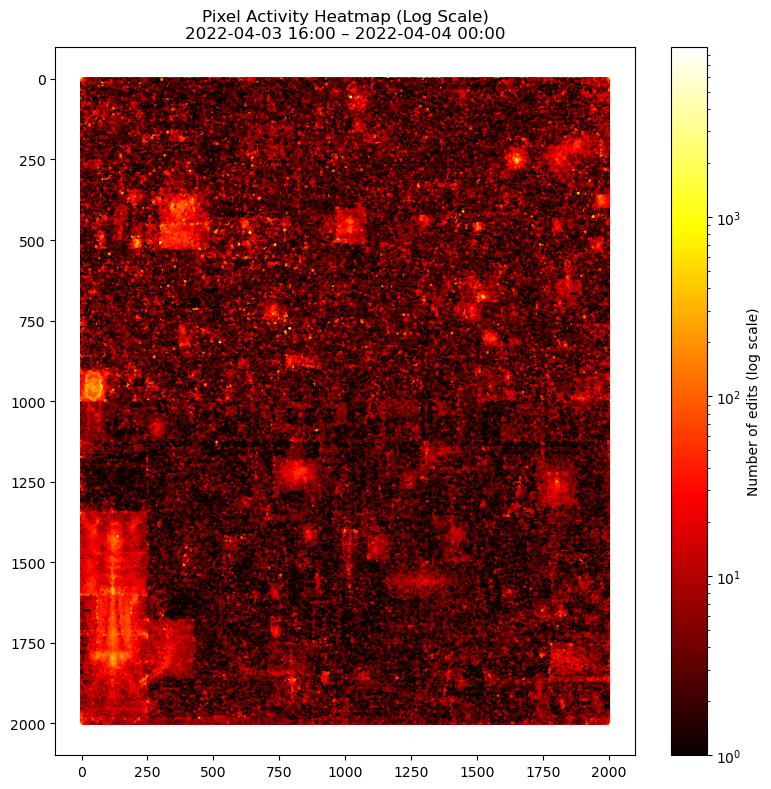

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 8))
plt.scatter(
    heat_df_1["x"],
    heat_df_1["y"],
    c=heat_df_1["edits"],
    s=1,
    cmap="hot",
    norm=LogNorm()
)
plt.colorbar(label="Number of edits (log scale)")
plt.title("Pixel Activity Heatmap (Log Scale)\n2022-04-03 16:00 – 2022-04-04 00:00")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [60]:
heat_df_2 = con.execute("""
SELECT
  x,
  y,
  COUNT(*) AS edits
FROM events
WHERE timestamp >= TIMESTAMP '2022-04-04 16:00:00'
  AND timestamp <  TIMESTAMP '2022-04-05 00:00:00'
GROUP BY 1,2
""").fetchdf()

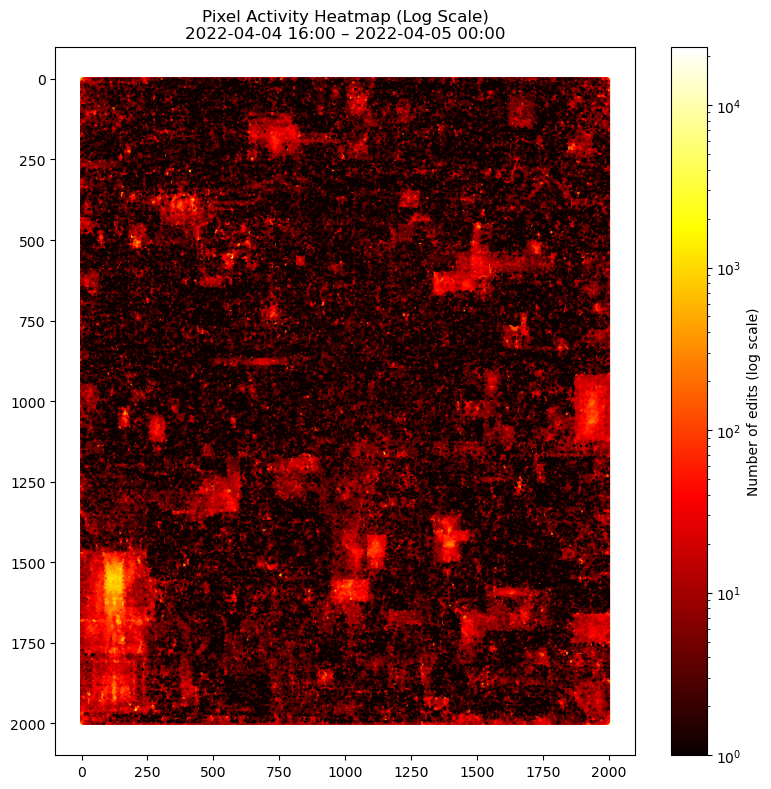

In [61]:
plt.figure(figsize=(8, 8))
plt.scatter(
    heat_df_2["x"],
    heat_df_2["y"],
    c=heat_df_2["edits"],
    s=1,
    cmap="hot",
    norm=LogNorm()
)
plt.colorbar(label="Number of edits (log scale)")
plt.title("Pixel Activity Heatmap (Log Scale)\n2022-04-04 16:00 – 2022-04-05 00:00")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()